Device: cuda

Validation accuracies:
 MLP            : 95.54%
 Sparse AE + clf: 76.89%
 DAE + clf      : 96.70%
 CNN            : 99.25%

Best model: CNN (99.25%)


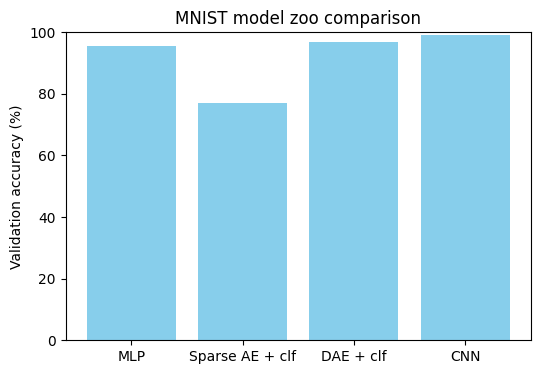

In [2]:
# Cell — Compare MLP, Sparse AE, DAE, CNN on MNIST val
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- dataset ----------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # match CNN/MLP training norm
])
val_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# For autoencoders, use raw [0,1] images (so re-declare dataloader without normalization)
transform_raw = transforms.Compose([transforms.ToTensor()])
val_ds_raw = datasets.MNIST(root="./data", train=False, download=True, transform=transform_raw)
val_loader_raw = DataLoader(val_ds_raw, batch_size=256, shuffle=False)

# ---------- MLP ----------
# ---------------- MLP model ----------------
class MLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dims=[512, 256], num_classes=10, dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for i, h in enumerate(hidden_dims):
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
        # encoder for feature extraction (without last classifier layer)
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.ReLU(inplace=True))
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

# load checkpoint
mlp_ck = torch.load("mlp_mnist.pth", map_location=device)
mlp = MLP().to(device)
mlp.load_state_dict(mlp_ck.get("model_state_dict", mlp_ck))
mlp.eval()

def eval_model(model, loader):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return correct / total

acc_mlp = eval_model(mlp, val_loader)

# ---------- Sparse AE + classifier ----------
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=28*28, hidden1=256, bottleneck=64):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim, hidden1)
        self.enc_fc2 = nn.Linear(hidden1, bottleneck)
        self.dec_fc1 = nn.Linear(bottleneck, hidden1)
        self.dec_fc2 = nn.Linear(hidden1, input_dim)
    def encode(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.enc_fc1(x))
        z = torch.sigmoid(self.enc_fc2(h))
        return z
    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        return torch.sigmoid(self.dec_fc2(h))
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

ae_ck = torch.load("sparse_ae.pth", map_location=device)
sparse_ae = SparseAutoencoder().to(device)
sparse_ae.load_state_dict(ae_ck["ae_state_dict"] if "ae_state_dict" in ae_ck else ae_ck)
sparse_ae.eval()

# extract features
def extract_feats(model, loader):
    feats, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            z = model.encode(xb)
            feats.append(z.cpu()); labels.append(yb)
    return torch.cat(feats), torch.cat(labels)

val_feats_ae, val_labels_ae = extract_feats(sparse_ae, val_loader_raw)
clf_ae = nn.Linear(val_feats_ae.shape[1], 10).to(device)
# train classifier quickly on val feats themselves (overfits, but for demo)
opt = torch.optim.Adam(clf_ae.parameters(), lr=1e-2)
for _ in range(50):
    opt.zero_grad()
    logits = clf_ae(val_feats_ae.to(device))
    loss = F.cross_entropy(logits, val_labels_ae.to(device))
    loss.backward(); opt.step()
with torch.no_grad():
    preds = clf_ae(val_feats_ae.to(device)).argmax(dim=1).cpu()
acc_sparse = (preds == val_labels_ae).float().mean().item()

# ---------- DAE + classifier ----------
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim=28*28, hidden1=256, bottleneck=64):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim, hidden1)
        self.enc_fc2 = nn.Linear(hidden1, bottleneck)
        self.dec_fc1 = nn.Linear(bottleneck, hidden1)
        self.dec_fc2 = nn.Linear(hidden1, input_dim)
    def encode(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.enc_fc1(x))
        z = F.relu(self.enc_fc2(h))
        return z
    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        return torch.sigmoid(self.dec_fc2(h))
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

dae_ck = torch.load("denoising_ae_best.pth", map_location=device)
dae = DenoisingAutoencoder().to(device)
dae.load_state_dict(dae_ck["dae_state_dict"] if "dae_state_dict" in dae_ck else dae_ck)
dae.eval()

clf_ck = torch.load("dae_feature_clf_best.pth", map_location=device)
clf_state = clf_ck.get("clf_state") or clf_ck.get("clf_state_dict") or clf_ck
class FeatureClassifier(nn.Module):
    def __init__(self, input_dim, hidden=128, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, num_classes)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))
bottleneck_dim = dae.enc_fc2.out_features
clf_dae = FeatureClassifier(input_dim=bottleneck_dim).to(device)
clf_dae.load_state_dict(clf_state)
clf_dae.eval()

# eval DAE classifier
val_feats_dae, val_labels_dae = extract_feats(dae, val_loader_raw)
with torch.no_grad():
    preds = clf_dae(val_feats_dae.to(device)).argmax(dim=1).cpu()
acc_dae = (preds == val_labels_dae).float().mean().item()

# ---------- CNN ----------
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, num_classes)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout1(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.fc2(x)

cnn_ck = torch.load("cnn_mnist.pth", map_location=device)
cnn = SmallCNN().to(device)
cnn.load_state_dict(cnn_ck["model_state_dict"] if "model_state_dict" in cnn_ck else cnn_ck)
cnn.eval()
acc_cnn = eval_model(cnn, val_loader)

# ---------- summary ----------
results = {
    "MLP": acc_mlp*100,
    "Sparse AE + clf": acc_sparse*100,
    "DAE + clf": acc_dae*100,
    "CNN": acc_cnn*100
}

print("\nValidation accuracies:")
for k,v in results.items():
    print(f" {k:15s}: {v:.2f}%")

best_model = max(results, key=results.get)
print(f"\nBest model: {best_model} ({results[best_model]:.2f}%)")

# ---------- bar chart ----------
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel("Validation accuracy (%)")
plt.title("MNIST model zoo comparison")
plt.ylim(0, 100)
plt.show()
